In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm

import os
os.makedirs("img", exist_ok=True)

In [3]:
scores_path = "data/promoterAI_tss500_SFSWAP.scores.tsv.gz"

TF = pd.read_csv("data/promoterAI_tss500_SFSWAP.promoterAI_v1_hg38_mm10_finetune.TF.tsv.gz", sep="\t")

TORCH   = pd.read_csv("data/promoterAI_tss500_SFSWAP.promoterAI_v1_hg38_mm10_finetune.TORCH.tsv.gz", sep="\t")
TF38    = pd.read_csv("data/promoterAI_tss500_SFSWAP.promoterAI_v1_hg38_finetune.TF.tsv.gz",         sep="\t")
TORCH38 = pd.read_csv("data/promoterAI_tss500_SFSWAP.promoterAI_v1_hg38_finetune.TORCH.tsv.gz",      sep="\t")

meta_cols = ["chrom", "pos", "ref", "alt", "gene", "gene_id", "transcript_id", "strand", "tss_pos"]
out = TF[meta_cols].copy()
out["tf_hg38_mm10_score"]    = TF["score"]
out["tf_hg38_score"]         = TF38["score"]
out["tf_avg_score"]          = (TF["score"] + TF38["score"]) / 2
out["torch_hg38_mm10_score"] = TORCH["score"]
out["torch_hg38_score"]      = TORCH38["score"]
out["torch_avg_score"]       = (TORCH["score"] + TORCH38["score"]) / 2
out.to_csv(scores_path, sep="\t", index=False)

out

,chrom,pos,ref,alt,gene,gene_id,transcript_id,strand,tss_pos,tf_hg38_mm10_score,tf_hg38_score,tf_avg_score,torch_hg38_mm10_score,torch_hg38_score,torch_avg_score
0,chr12,131710589,C,A,SFSWAP,ENSG00000061936,ENST00000261674.9,1,131711089,0.084597,0.074661,0.079629,0.084597,0.074661,0.079629
1,chr12,131710589,C,G,SFSWAP,ENSG00000061936,ENST00000261674.9,1,131711089,-0.007300,-0.015399,-0.011349,-0.007300,-0.015399,-0.011349
2,chr12,131710589,C,T,SFSWAP,ENSG00000061936,ENST00000261674.9,1,131711089,0.034686,0.011699,0.023193,0.034686,0.011699,0.023193
3,chr12,131710590,A,C,SFSWAP,ENSG00000061936,ENST00000261674.9,1,131711089,0.062419,-0.001600,0.030409,0.062419,-0.001600,0.030409
4,chr12,131710590,A,G,SFSWAP,ENSG00000061936,ENST00000261674.9,1,131711089,-0.023596,-0.005400,-0.014498,-0.023596,-0.005400,-0.014498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9004,chr12,131753621,T,C,SFSWAP,ENSG00000061936,ENST00000537164.1,1,131753122,-0.017798,0.007900,-0.004949,-0.017798,0.007900,-0.004949
9005,chr12,131753621,T,G,SFSWAP,ENSG00000061936,ENST00000537164.1,1,131753122,0.022896,0.015799,0.019347,0.022896,0.015799,0.019347
9006,chr12,131753622,C,A,SFSWAP,ENSG00000061936,ENST00000537164.1,1,131753122,0.006400,0.002000,0.004200,0.006400,0.002000,0.004200
9007,chr12,131753622,C,G,SFSWAP,ENSG00000061936,ENST00000537164.1,1,131753122,0.012899,-0.026694,-0.006897,0.012899,-0.026694,-0.006897


TF score (hg38_mm10) vs Torch score (hg38_mm10): r=1.0000, MAE=0.0000
TF score (hg38) vs Torch score (hg38): r=1.0000, MAE=0.0000
TF avg score vs Torch avg score: r=1.0000, MAE=0.0000
Published score vs TF avg score: r=1.0000, MAE=0.0000
Published score vs Torch avg score: r=1.0000, MAE=0.0000


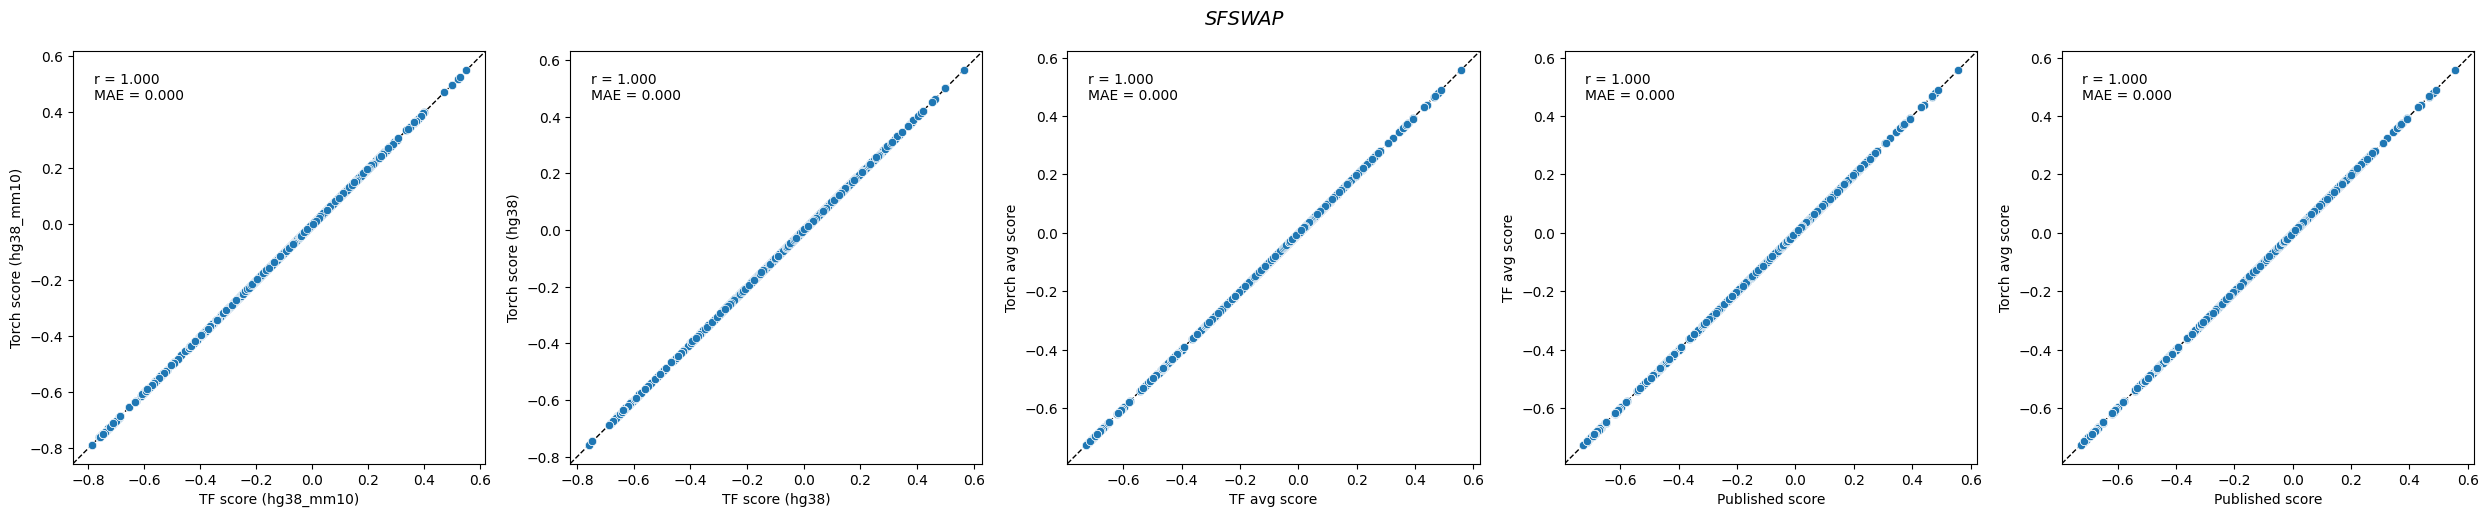

In [4]:
scatter_pairs = [
    (out["tf_hg38_mm10_score"], out["torch_hg38_mm10_score"], "TF score (hg38_mm10)", "Torch score (hg38_mm10)"),
    (out["tf_hg38_score"],      out["torch_hg38_score"],      "TF score (hg38)",      "Torch score (hg38)"),
    (out["tf_avg_score"],       out["torch_avg_score"],       "TF avg score",         "Torch avg score"),
    (TF["promoterAI"],          out["tf_avg_score"],          "Published score",      "TF avg score"),
    (TF["promoterAI"],          out["torch_avg_score"],       "Published score",      "Torch avg score"),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("SFSWAP", fontsize=14, fontstyle="italic")
for ax, (x, y, xlabel, ylabel) in zip(axes, scatter_pairs):
    sns.scatterplot(x=x, y=y, ax=ax)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", linewidth=1, zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    r, _ = pearsonr(x, y)
    mae = (x - y).abs().mean()
    print(f"{xlabel} vs {ylabel}: r={r:.4f}, MAE={mae:.4f}")
    ax.annotate(f"r = {r:.3f}\nMAE = {mae:.3f}", xy=(0.05, 0.95), xycoords="axes fraction", va="top")

plt.tight_layout()
fig.savefig("img/SFSWAP_scatter.svg", bbox_inches="tight")

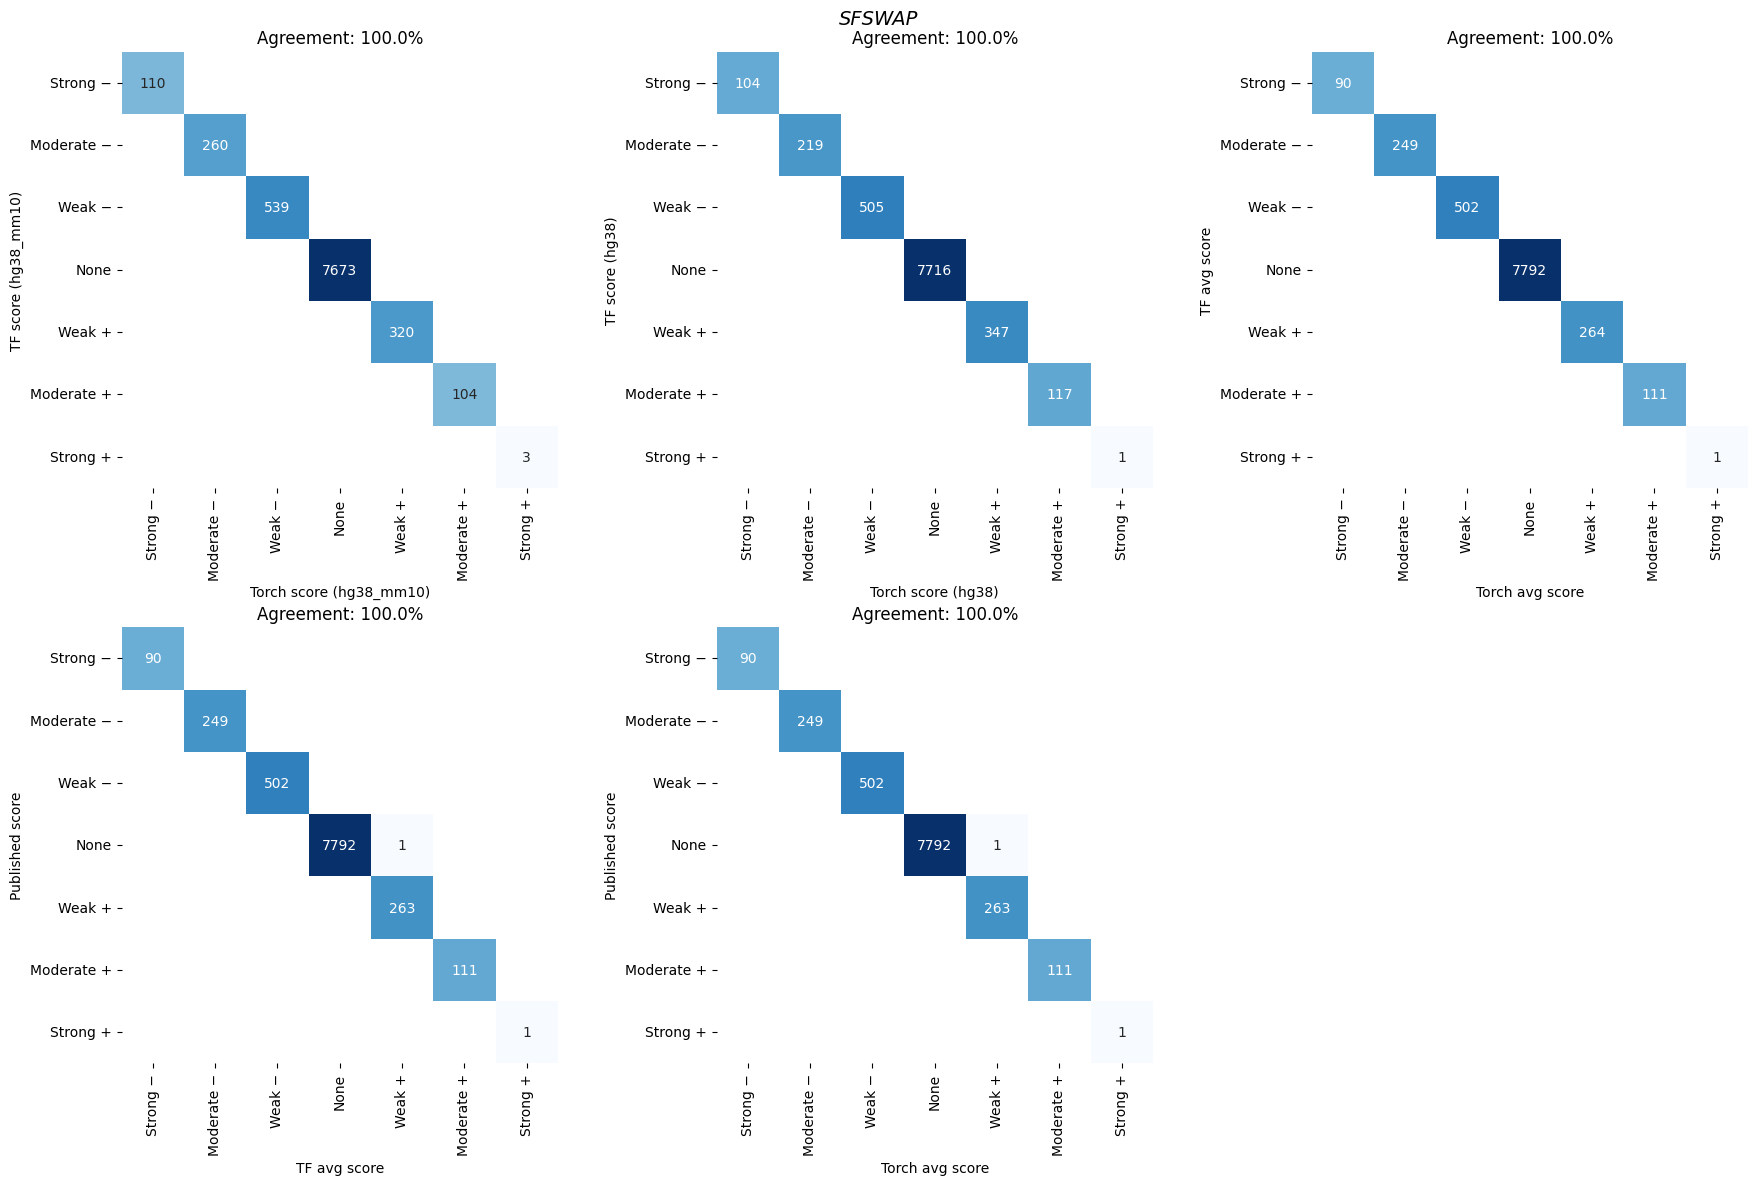

In [5]:
def classify(s):
    bins = [-float("inf"), -0.5, -0.2, -0.1, 0.1, 0.2, 0.5, float("inf")]
    labels = ["Strong −", "Moderate −", "Weak −", "None", "Weak +", "Moderate +", "Strong +"]
    return pd.cut(s, bins=bins, labels=labels)

order = classify(out["tf_hg38_mm10_score"][:1]).cat.categories.tolist()

concordance_pairs = [
    (out["tf_hg38_mm10_score"], out["torch_hg38_mm10_score"], "TF score (hg38_mm10)", "Torch score (hg38_mm10)"),
    (out["tf_hg38_score"],      out["torch_hg38_score"],      "TF score (hg38)",      "Torch score (hg38)"),
    (out["tf_avg_score"],       out["torch_avg_score"],       "TF avg score",         "Torch avg score"),
    (TF["promoterAI"],          out["tf_avg_score"],          "Published score",      "TF avg score"),
    (TF["promoterAI"],          out["torch_avg_score"],       "Published score",      "Torch avg score"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("SFSWAP", fontsize=14, fontstyle="italic")
for ax, (x, y, xlabel, ylabel) in zip(axes.flat, concordance_pairs):
    ct = pd.crosstab(classify(x), classify(y))
    ct = ct.reindex(index=order, columns=order, fill_value=0)
    vmin = ct.values[ct.values > 0].min()
    sns.heatmap(ct, ax=ax, annot=True, fmt="d", cmap="Blues",
                norm=LogNorm(vmin=vmin, vmax=ct.values.max()),
                xticklabels=order, yticklabels=order, cbar=False, square=True)
    ax.set_xlabel(ylabel)
    ax.set_ylabel(xlabel)
    total = ct.values.sum()
    agree = ct.values.diagonal().sum()
    ax.set_title(f"Agreement: {agree/total:.1%}")

axes.flat[-1].set_visible(False)
plt.tight_layout()
fig.savefig("img/SFSWAP_cutoff_concordance.svg", bbox_inches="tight")